# Exploratory Data Analysis — Aromatase (CYP19A1) Inhibitors

**Dataset**: Curated, non-redundant bioactivity data from ChEMBL (target CHEMBL1978).  
**Pipeline step**: Step 4 — EDA prior to QSAR modelling.

---

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# RDKit
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Lipinski

# Sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

RDLogger.logger().setLevel(RDLogger.ERROR)

# Plot style
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 6)

print("All imports OK")

All imports OK


In [2]:
# Load curated bioactivity data
DATA_DIR = "../data/processed"
FP_DIR   = "../data/fingerprints"

df = pd.read_csv(f"{DATA_DIR}/aromatase_bioactivity_clean.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Dataset shape: (3774, 19)
Columns: ['molecule_chembl_id', 'molecule_pref_name', 'canonical_smiles', 'standard_type', 'standard_relation', 'standard_value', 'standard_units', 'pchembl_value', 'assay_chembl_id', 'assay_description', 'assay_type', 'target_chembl_id', 'target_pref_name', 'target_organism', 'document_chembl_id', 'document_journal', 'document_year', 'activity_id', 'inchi_key']


,molecule_chembl_id,molecule_pref_name,canonical_smiles,standard_type,standard_relation,standard_value,standard_units,pchembl_value,assay_chembl_id,assay_description,assay_type,target_chembl_id,target_pref_name,target_organism,document_chembl_id,document_journal,document_year,activity_id,inchi_key
0,CHEMBL10026,NaN,O=C1/C(=C/c2ccncc2)C(c2ccccc2)Oc2ccccc21,IC50,=,800.0,nM,6.10,CHEMBL666797,"In vitro inhibition of [1,2,6,7-3H]-androstene...",B,CHEMBL1978,Aromatase,Homo sapiens,CHEMBL1135267,Bioorg Med Chem Lett,2002,287165,YQBABXZFWNTIHJ-JXAWBTAJSA-N
1,CHEMBL100615,NaN,C[C@]12CCC(=O)C=C1C[C@@H](Sc1ccc(NC(=O)CBr)cc1...,Ki,=,33000.0,nM,4.48,CHEMBL661762,Binding affinity was measured on Cytochrome P4...,B,CHEMBL1978,Aromatase,Homo sapiens,CHEMBL1124997,J Med Chem,1990,622174,LCFDGVXDFUKBGU-BWGWWWHMSA-N
2,CHEMBL10072,NaN,O=C1/C(=C\c2ccncc2)C(c2ccccc2)Oc2ccccc21,IC50,=,3300.0,nM,5.48,CHEMBL666797,"In vitro inhibition of [1,2,6,7-3H]-androstene...",B,CHEMBL1978,Aromatase,Homo sapiens,CHEMBL1135267,Bioorg Med Chem Lett,2002,280184,YQBABXZFWNTIHJ-NBVRZTHBSA-N


In [3]:
# Quick overview
print(f"Records:           {len(df):,}")
print(f"Unique molecules:  {df['molecule_chembl_id'].nunique():,}")
print(f"Unique assays:     {df['assay_chembl_id'].nunique():,}")
print(f"Year range:        {df['document_year'].min()} – {df['document_year'].max()}")
print(f"pchembl non-null:  {df['pchembl_value'].notna().sum():,} / {len(df):,}")
print()
df.describe(include="all").T

Records:           3,774
Unique molecules:  3,399
Unique assays:     327
Year range:        1978 – 2024
pchembl non-null:  3,296 / 3,774



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
molecule_chembl_id,3774,3399,CHEMBL1630280,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
molecule_pref_name,154,134,FORMESTANE,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canonical_smiles,3774,3399,C[C@]12CC[C@@H](O)C(=O)[C@@H]1CC[C@@H]1[C@@H]2...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_type,3774,3,IC50,3211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_relation,3679,3,=,3403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_value,3679.0,NaN,NaN,NaN,5885658636.433019,209264102481.267426,-2.176,72.0,859.01,7120.335,9098504302049.910156
standard_units,3690,3,nM,3632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pchembl_value,3296.0,NaN,NaN,NaN,6.367064,1.260443,4.0,5.4,6.228333,7.2,10.82
assay_chembl_id,3774,327,CHEMBL5376029,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assay_description,3774,271,Inhibition of human aromatase using ASD as sub...,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Bioactivity Distribution Analysis

Records with pchembl_value: 3,296


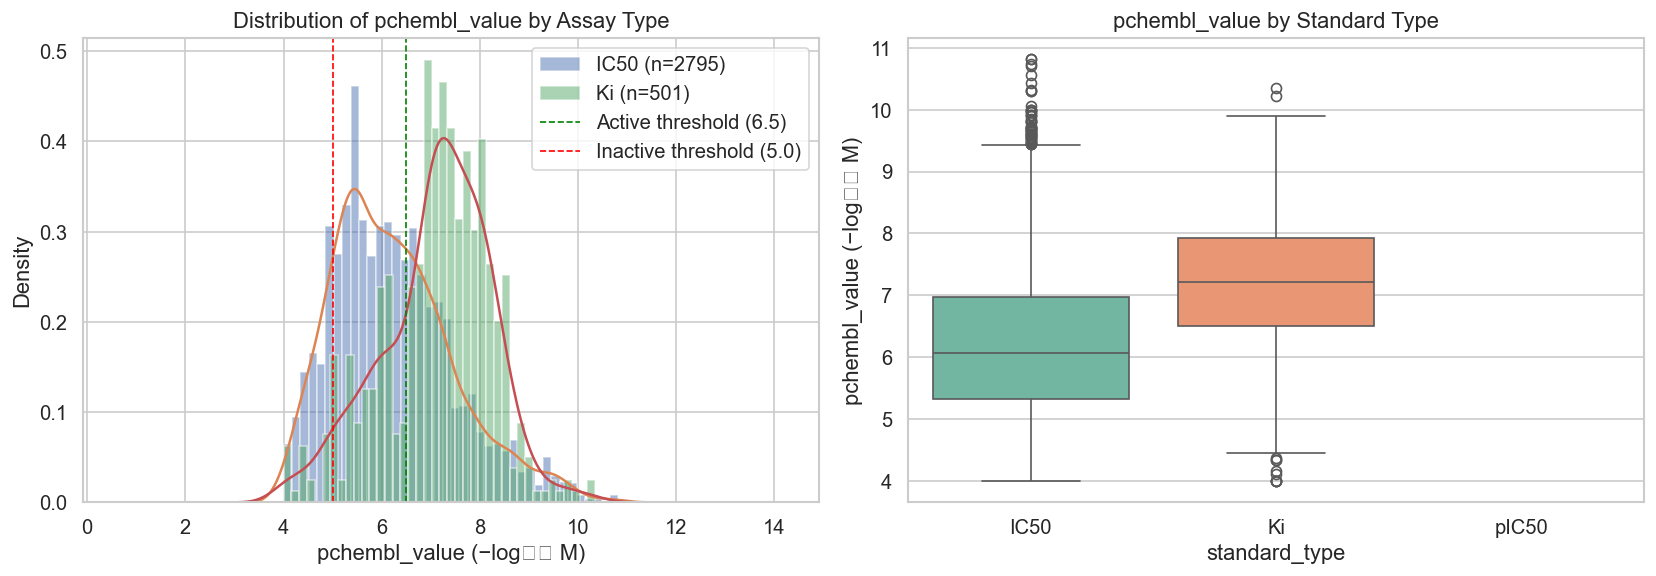

In [4]:
# pchembl_value distribution by standard_type
pch = df.dropna(subset=["pchembl_value"])
print(f"Records with pchembl_value: {len(pch):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
for st in ["IC50", "Ki", "pIC50"]:
    sub = pch[pch["standard_type"] == st]["pchembl_value"]
    if len(sub) > 0:
        axes[0].hist(sub, bins=40, alpha=0.5, label=f"{st} (n={len(sub)})", density=True)
        sub.plot.kde(ax=axes[0], label=f"_{st}")  # underscore hides from legend
axes[0].set_xlabel("pchembl_value (−log₁₀ M)")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of pchembl_value by Assay Type")
axes[0].legend()
axes[0].axvline(6.5, color="green", ls="--", lw=1, label="Active threshold (6.5)")
axes[0].axvline(5.0, color="red",   ls="--", lw=1, label="Inactive threshold (5.0)")
axes[0].legend()

# Box plot
sns.boxplot(data=pch, x="standard_type", y="pchembl_value", ax=axes[1],
            order=["IC50", "Ki", "pIC50"], palette="Set2")
axes[1].set_title("pchembl_value by Standard Type")
axes[1].set_ylabel("pchembl_value (−log₁₀ M)")

plt.tight_layout()
plt.show()

Activity class distribution:
activity_class
Active          1435
Intermediate    1431
Unknown          478
Inactive         430
Name: count, dtype: int64



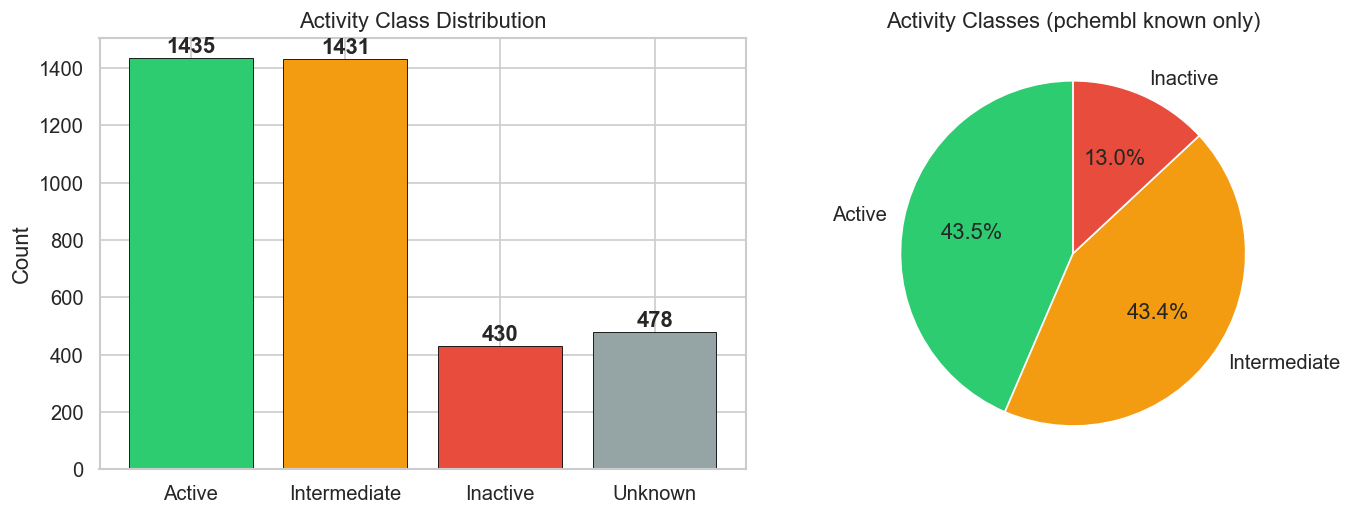


Class balance (known only): {'Active': np.int64(1435), 'Intermediate': np.int64(1431), 'Inactive': np.int64(430)}
Active : Inactive ratio = 1435 : 430 = 1 : 0.30


In [5]:
# Define activity classes (standard QSAR thresholds)
def classify_activity(val):
    if pd.isna(val):
        return "Unknown"
    if val >= 6.5:
        return "Active"
    elif val < 5.0:
        return "Inactive"
    else:
        return "Intermediate"

df["activity_class"] = df["pchembl_value"].apply(classify_activity)
class_counts = df["activity_class"].value_counts()
print("Activity class distribution:")
print(class_counts)
print()

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = {"Active": "#2ecc71", "Intermediate": "#f39c12", "Inactive": "#e74c3c", "Unknown": "#95a5a6"}
order = ["Active", "Intermediate", "Inactive", "Unknown"]
present = [c for c in order if c in class_counts.index]

axes[0].bar(present, [class_counts[c] for c in present],
            color=[colors[c] for c in present], edgecolor="black", linewidth=0.5)
for i, c in enumerate(present):
    axes[0].text(i, class_counts[c] + 20, str(class_counts[c]), ha="center", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_title("Activity Class Distribution")

# Pie (excluding Unknown for modeling perspective)
known = class_counts.drop("Unknown", errors="ignore")
axes[1].pie(known, labels=known.index, autopct="%1.1f%%",
            colors=[colors[c] for c in known.index], startangle=90)
axes[1].set_title("Activity Classes (pchembl known only)")

plt.tight_layout()
plt.show()

print(f"\nClass balance (known only): {dict(known)}")
print(f"Active : Inactive ratio = {known.get('Active',0)} : {known.get('Inactive',0)}"
      f" = 1 : {known.get('Inactive',0)/max(known.get('Active',1),1):.2f}")

## 3. Data Quality & Completeness

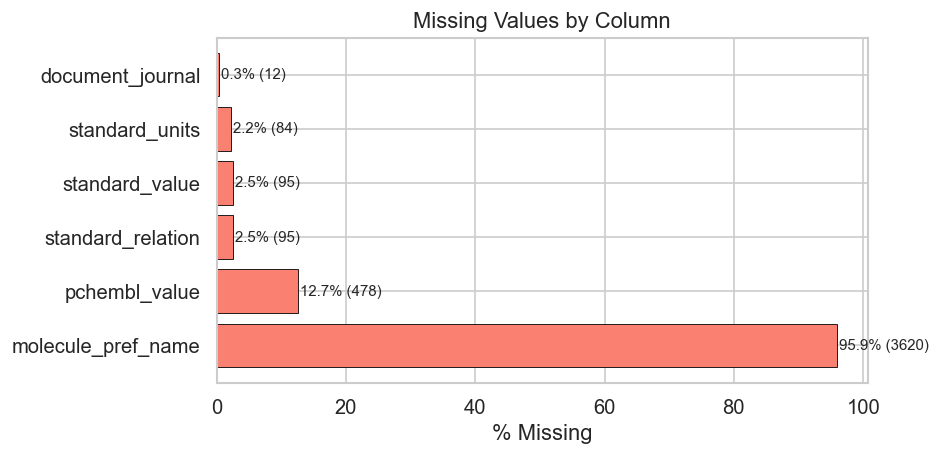

In [6]:
# Missing value heatmap
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(null_pct.index, null_pct.values, color="salmon", edgecolor="black", linewidth=0.5)
ax.set_xlabel("% Missing")
ax.set_title("Missing Values by Column")
for i, (col, pct) in enumerate(null_pct.items()):
    ax.text(pct + 0.3, i, f"{pct:.1f}% ({df[col].isnull().sum()})", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# Standard relation breakdown — exact vs censored measurements
rel_counts = df["standard_relation"].value_counts(dropna=False)
print("standard_relation breakdown:")
print(rel_counts)
print()

n_exact    = (df["standard_relation"] == "=").sum()
n_censored = df["standard_relation"].isin([">", ">="]).sum()
n_missing  = df["standard_relation"].isna().sum()
print(f"Exact measurements (=):   {n_exact:,} ({n_exact/len(df)*100:.1f}%)")
print(f"Censored (> or >=):       {n_censored:,} ({n_censored/len(df)*100:.1f}%)")
print(f"Missing relation:         {n_missing:,} ({n_missing/len(df)*100:.1f}%)")
print()
print("⚠ Censored measurements mean the true potency could be higher —")
print("  consider filtering to '=' only for regression models, or using")
print("  censored data for classification (active/inactive).")

standard_relation breakdown:
standard_relation
=      3403
>       275
NaN      95
>=        1
Name: count, dtype: int64

Exact measurements (=):   3,403 (90.2%)
Censored (> or >=):       276 (7.3%)
Missing relation:         95 (2.5%)

⚠ Censored measurements mean the true potency could be higher —
  consider filtering to '=' only for regression models, or using
  censored data for classification (active/inactive).


In [8]:
# Unit heterogeneity
unit_counts = df["standard_units"].value_counts(dropna=False)
print("Standard units breakdown:")
print(unit_counts)
print()

non_nm = df[~df["standard_units"].isin(["nM"]) & df["standard_units"].notna()]
print(f"Non-nM entries: {len(non_nm)} ({len(non_nm)/len(df)*100:.1f}%)")
print("Note: pchembl_value is already standardised to −log₁₀(M) by ChEMBL,")
print("so unit differences are absorbed. But raw standard_value is unit-dependent.")

Standard units breakdown:
standard_units
nM         3632
NaN          84
uM           30
ug.mL-1      28
Name: count, dtype: int64

Non-nM entries: 58 (1.5%)
Note: pchembl_value is already standardised to −log₁₀(M) by ChEMBL,
so unit differences are absorbed. But raw standard_value is unit-dependent.


Molecules tested in multiple assay types: 361 / 3399
Molecules with >1 record: 361



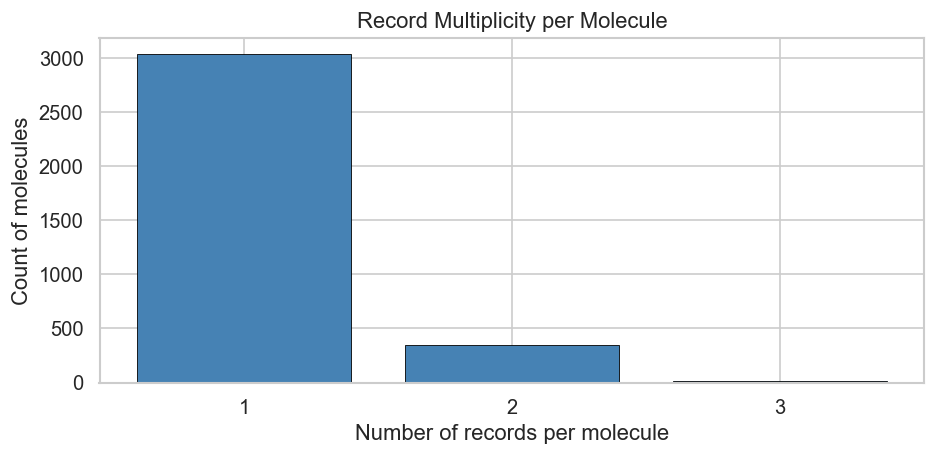

In [9]:
# Duplicate molecules across assay types
mol_assay = df.groupby("molecule_chembl_id").agg(
    n_records=("activity_id", "count"),
    n_assay_types=("standard_type", "nunique"),
    assay_types=("standard_type", lambda x: ", ".join(sorted(x.unique())))
)

multi_type = mol_assay[mol_assay["n_assay_types"] > 1]
print(f"Molecules tested in multiple assay types: {len(multi_type)} / {len(mol_assay)}")
print(f"Molecules with >1 record: {(mol_assay['n_records'] > 1).sum()}")
print()

fig, ax = plt.subplots(figsize=(8, 4))
rec_dist = mol_assay["n_records"].value_counts().sort_index()
ax.bar(rec_dist.index[:15], rec_dist.values[:15], color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of records per molecule")
ax.set_ylabel("Count of molecules")
ax.set_title("Record Multiplicity per Molecule")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 4. Temporal Trends

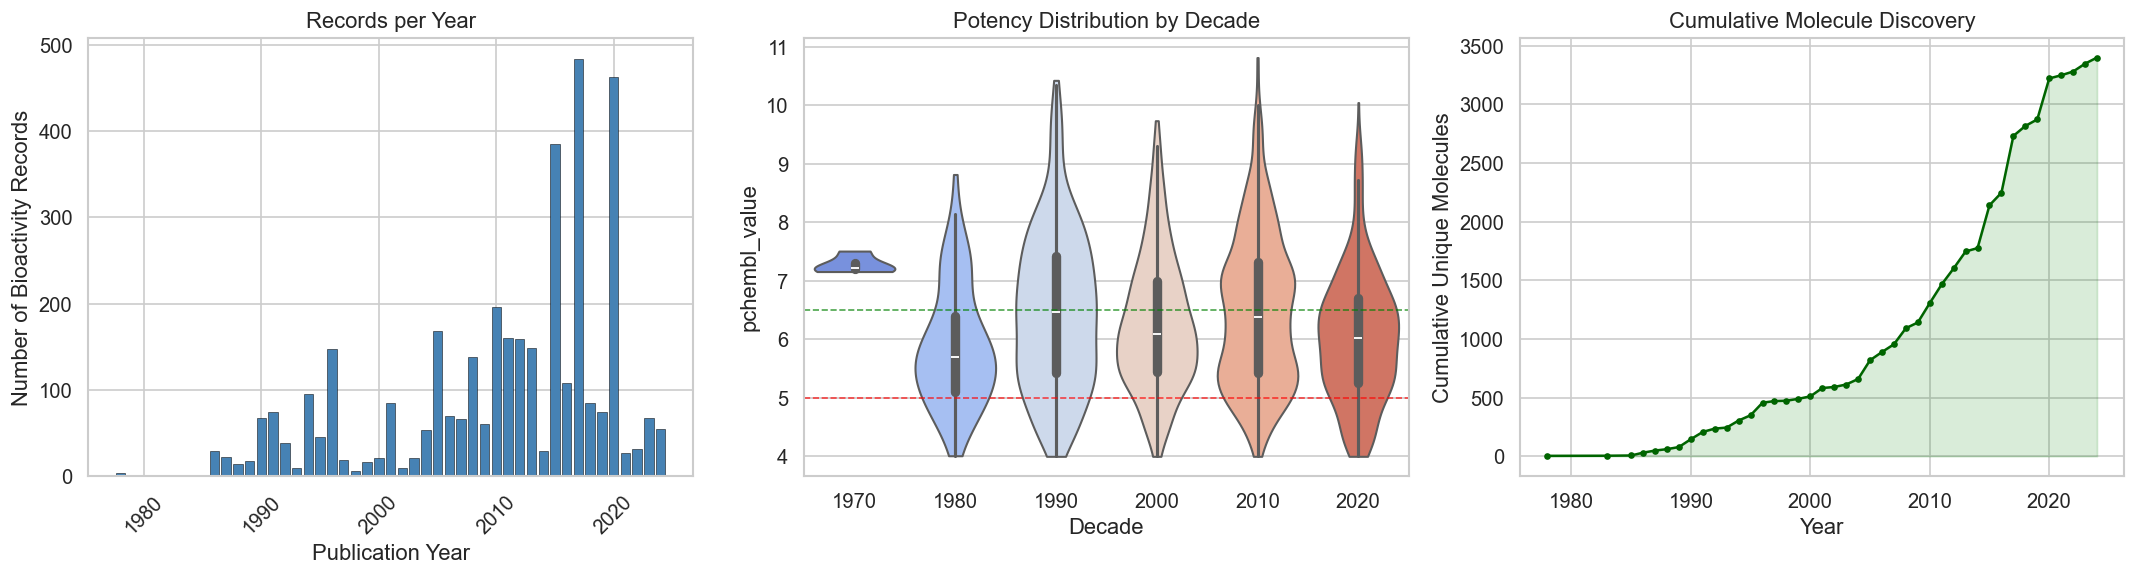

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Publications per year
year_counts = df["document_year"].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color="steelblue", edgecolor="black", linewidth=0.3)
axes[0].set_xlabel("Publication Year")
axes[0].set_ylabel("Number of Bioactivity Records")
axes[0].set_title("Records per Year")
axes[0].tick_params(axis="x", rotation=45)

# Potency over time (violin per decade)
pch_year = df.dropna(subset=["pchembl_value"]).copy()
pch_year["decade"] = (pch_year["document_year"] // 10) * 10
decade_order = sorted(pch_year["decade"].unique())
sns.violinplot(data=pch_year, x="decade", y="pchembl_value", ax=axes[1],
               order=decade_order, palette="coolwarm", inner="box", cut=0)
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("pchembl_value")
axes[1].set_title("Potency Distribution by Decade")
axes[1].axhline(6.5, color="green", ls="--", lw=1, alpha=0.7)
axes[1].axhline(5.0, color="red", ls="--", lw=1, alpha=0.7)

# Cumulative discovery curve
first_seen = df.groupby("molecule_chembl_id")["document_year"].min().sort_values()
cumul = first_seen.value_counts().sort_index().cumsum()
axes[2].plot(cumul.index, cumul.values, "o-", color="darkgreen", markersize=3)
axes[2].fill_between(cumul.index, cumul.values, alpha=0.15, color="green")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Cumulative Unique Molecules")
axes[2].set_title("Cumulative Molecule Discovery")

plt.tight_layout()
plt.show()

## 5. Molecular Property Distributions (Lipinski & Drug-likeness)

In [11]:
# Compute molecular descriptors from SMILES
def compute_descriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return [np.nan] * 8
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.NumAromaticRings(mol),
        Descriptors.FractionCSP3(mol),
    ]

desc_cols = ["MW", "LogP", "HBA", "HBD", "TPSA", "RotBonds", "AromaticRings", "FractionCSP3"]
print("Computing molecular descriptors (this may take ~30s)...")
desc_data = df["canonical_smiles"].apply(compute_descriptors)
desc_df = pd.DataFrame(desc_data.tolist(), columns=desc_cols, index=df.index)
df = pd.concat([df, desc_df], axis=1)
print(f"Descriptors computed for {desc_df.notna().all(axis=1).sum()} / {len(df)} molecules")
df[desc_cols].describe()

Computing molecular descriptors (this may take ~30s)...


Descriptors computed for 3774 / 3774 molecules


,MW,LogP,HBA,HBD,TPSA,RotBonds,AromaticRings,FractionCSP3
count,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000
mean,342.625021,4.067122,3.328829,0.655803,54.894518,3.607578,2.096979,0.361203
std,115.676916,1.400325,1.810747,0.993470,32.721078,2.974751,1.562083,0.289405
min,130.078000,-1.402800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,286.415000,3.165730,2.000000,0.000000,34.140000,1.250000,1.000000,0.111111
50%,322.404000,4.000700,3.000000,0.000000,46.530000,3.000000,2.000000,0.250000
75%,374.800750,4.860700,4.000000,1.000000,66.490000,5.000000,3.000000,0.647059
max,1815.182000,11.508920,16.000000,9.000000,245.290000,28.000000,10.000000,1.000000


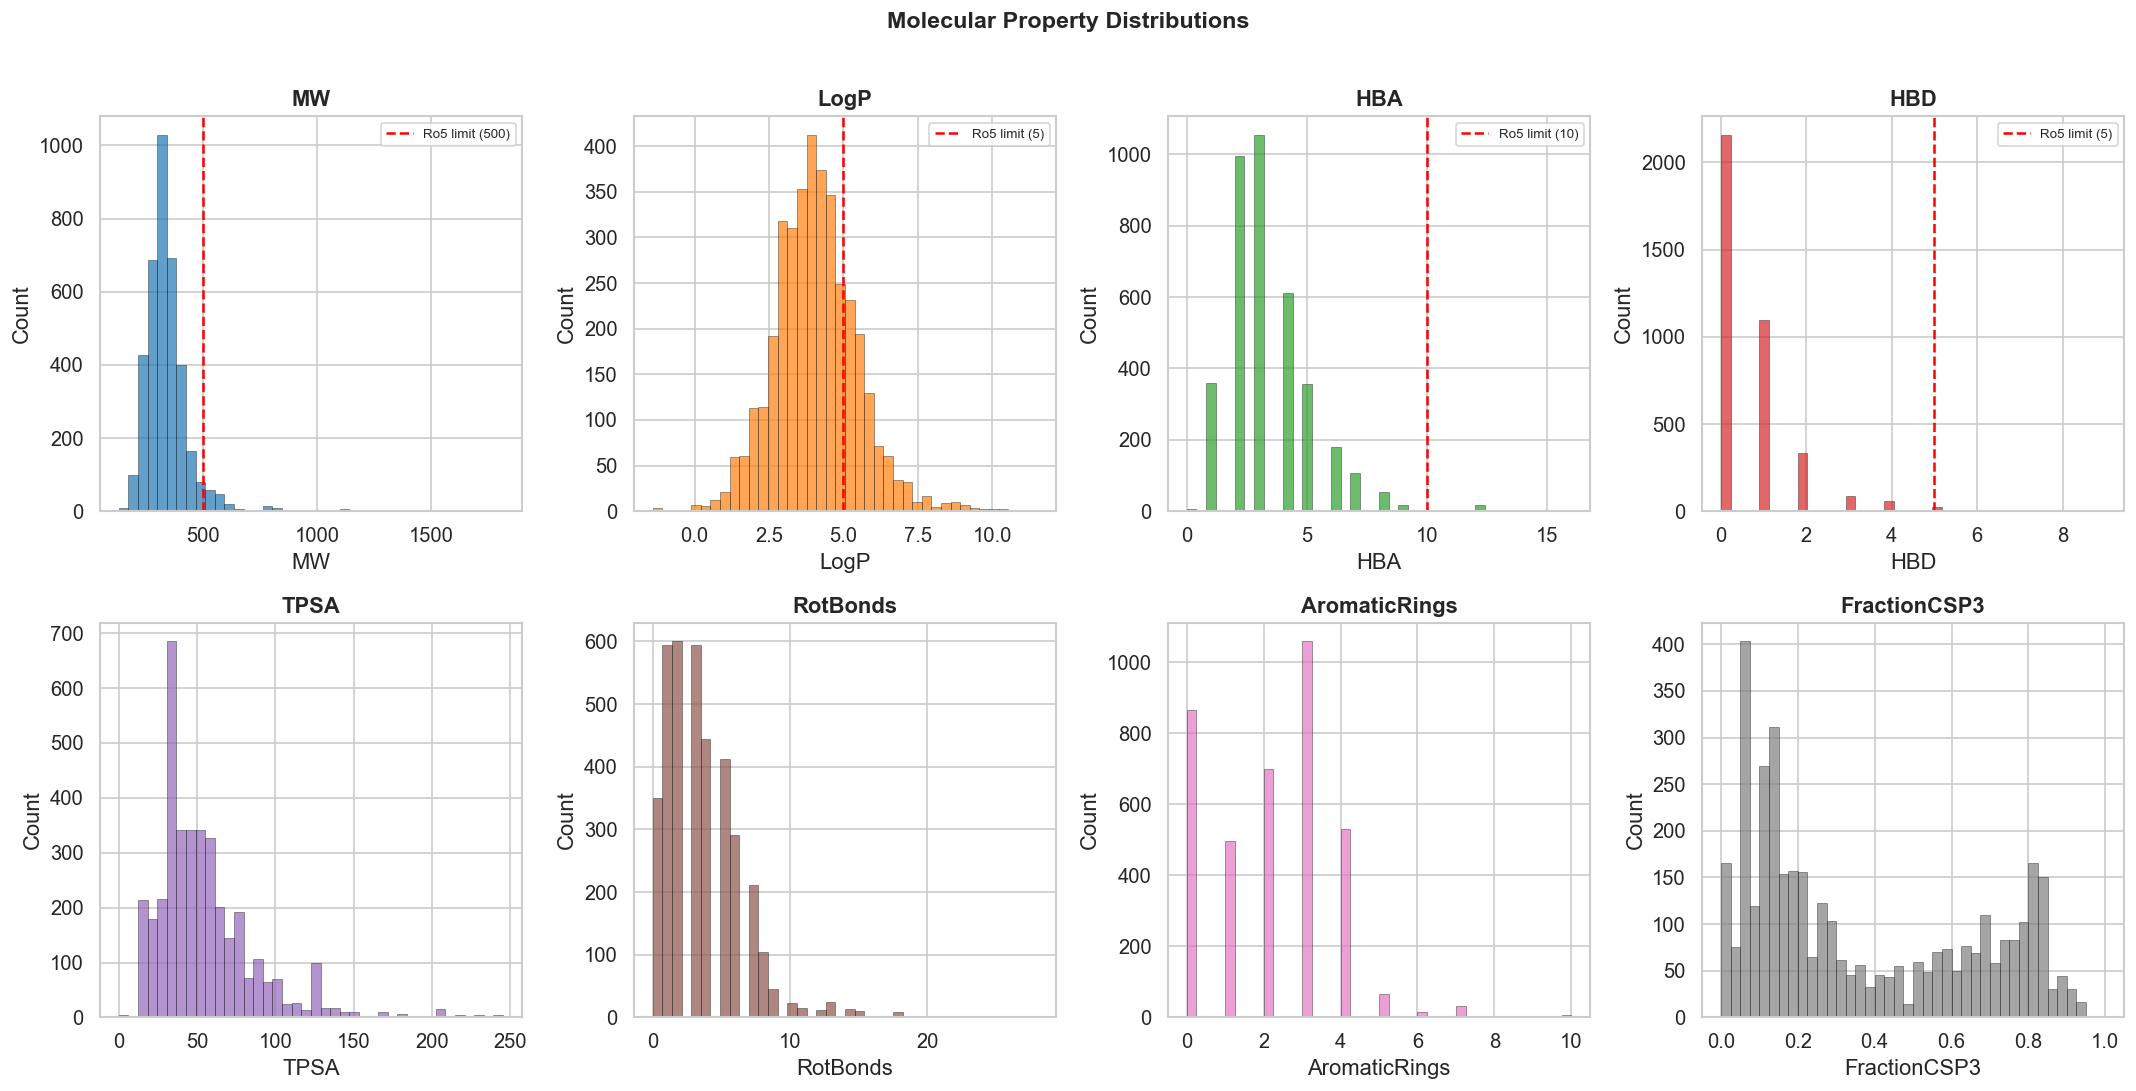

In [12]:
# Histograms of molecular properties
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

lipinski_limits = {"MW": 500, "LogP": 5, "HBA": 10, "HBD": 5}
colors_prop = sns.color_palette("tab10", 8)

for i, col in enumerate(desc_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color=colors_prop[i], alpha=0.7, edgecolor="black", linewidth=0.3)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Count")
    # Lipinski limits
    if col in lipinski_limits:
        ax.axvline(lipinski_limits[col], color="red", ls="--", lw=1.5,
                   label=f"Ro5 limit ({lipinski_limits[col]})")
        ax.legend(fontsize=8)
    ax.set_xlabel(col)

plt.suptitle("Molecular Property Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

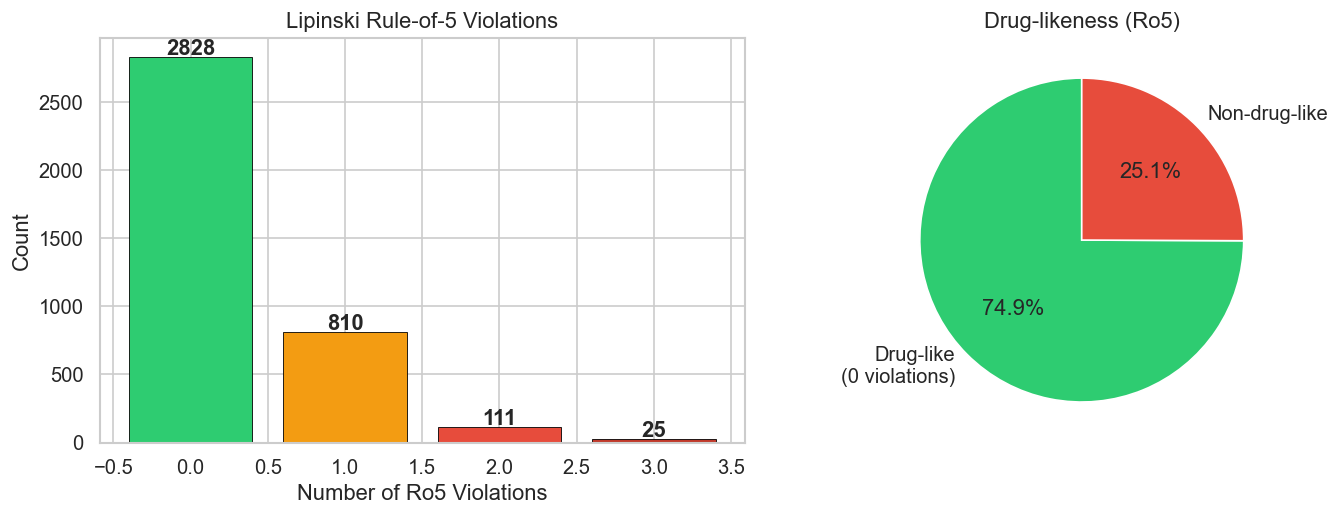

Drug-like molecules (0 Ro5 violations): 2828 / 3774 (74.9%)


In [13]:
# Lipinski Rule-of-5 compliance
def lipinski_pass(row):
    violations = 0
    if row["MW"]   > 500: violations += 1
    if row["LogP"] > 5:   violations += 1
    if row["HBA"]  > 10:  violations += 1
    if row["HBD"]  > 5:   violations += 1
    return violations

df["Ro5_violations"] = df.apply(lipinski_pass, axis=1)
ro5_counts = df["Ro5_violations"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(ro5_counts.index, ro5_counts.values, color=["#2ecc71", "#f39c12", "#e74c3c", "#c0392b"],
            edgecolor="black", linewidth=0.5)
for i, (v, c) in enumerate(ro5_counts.items()):
    axes[0].text(v, c + 20, str(c), ha="center", fontweight="bold")
axes[0].set_xlabel("Number of Ro5 Violations")
axes[0].set_ylabel("Count")
axes[0].set_title("Lipinski Rule-of-5 Violations")

# Drug-like (0 violations) percentage
drug_like_pct = (df["Ro5_violations"] == 0).mean() * 100
axes[1].pie([drug_like_pct, 100 - drug_like_pct],
            labels=["Drug-like\n(0 violations)", "Non-drug-like"],
            colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Drug-likeness (Ro5)")

plt.tight_layout()
plt.show()

print(f"Drug-like molecules (0 Ro5 violations): {(df['Ro5_violations']==0).sum()} / {len(df)} ({drug_like_pct:.1f}%)")

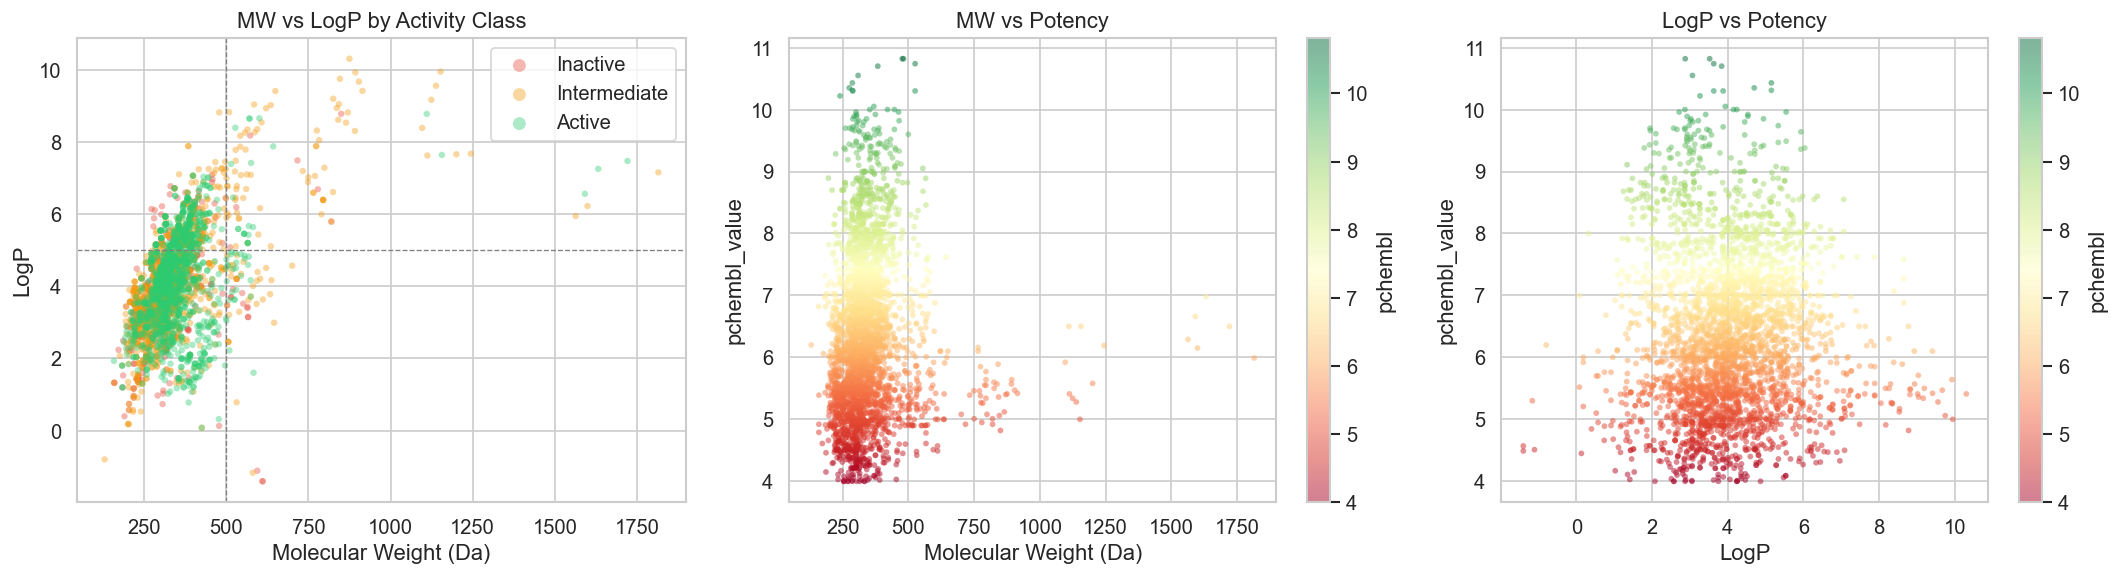

In [14]:
# Scatter: MW vs LogP, coloured by activity class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

color_map = {"Active": "#2ecc71", "Intermediate": "#f39c12", "Inactive": "#e74c3c", "Unknown": "#95a5a6"}
plot_df = df.dropna(subset=["MW", "LogP"])

for cls in ["Inactive", "Intermediate", "Active"]:
    sub = plot_df[plot_df["activity_class"] == cls]
    axes[0].scatter(sub["MW"], sub["LogP"], c=color_map[cls], label=cls,
                    alpha=0.4, s=15, edgecolors="none")
axes[0].set_xlabel("Molecular Weight (Da)")
axes[0].set_ylabel("LogP")
axes[0].set_title("MW vs LogP by Activity Class")
axes[0].legend(markerscale=2)
axes[0].axvline(500, color="grey", ls="--", lw=0.8)
axes[0].axhline(5, color="grey", ls="--", lw=0.8)

# MW vs pchembl
sub = df.dropna(subset=["MW", "pchembl_value"])
sc = axes[1].scatter(sub["MW"], sub["pchembl_value"], c=sub["pchembl_value"],
                     cmap="RdYlGn", s=12, alpha=0.5, edgecolors="none")
axes[1].set_xlabel("Molecular Weight (Da)")
axes[1].set_ylabel("pchembl_value")
axes[1].set_title("MW vs Potency")
plt.colorbar(sc, ax=axes[1], label="pchembl")

# LogP vs pchembl
sub2 = df.dropna(subset=["LogP", "pchembl_value"])
sc2 = axes[2].scatter(sub2["LogP"], sub2["pchembl_value"], c=sub2["pchembl_value"],
                      cmap="RdYlGn", s=12, alpha=0.5, edgecolors="none")
axes[2].set_xlabel("LogP")
axes[2].set_ylabel("pchembl_value")
axes[2].set_title("LogP vs Potency")
plt.colorbar(sc2, ax=axes[2], label="pchembl")

plt.tight_layout()
plt.show()

## 6. Chemical Space Visualization (ECFP4)

In [15]:
# Load ECFP4 fingerprints
fp_ecfp4 = pd.read_csv(f"{FP_DIR}/fingerprints_ecfp4.csv")
print(f"ECFP4 shape: {fp_ecfp4.shape}")

# Separate ID column from bit columns
fp_id = fp_ecfp4.iloc[:, 0]  # molecule_chembl_id
X_ecfp4 = fp_ecfp4.iloc[:, 1:].values  # 1024 bits
print(f"Fingerprint matrix: {X_ecfp4.shape}")

ECFP4 shape: (3774, 1025)
Fingerprint matrix: (3774, 1024)


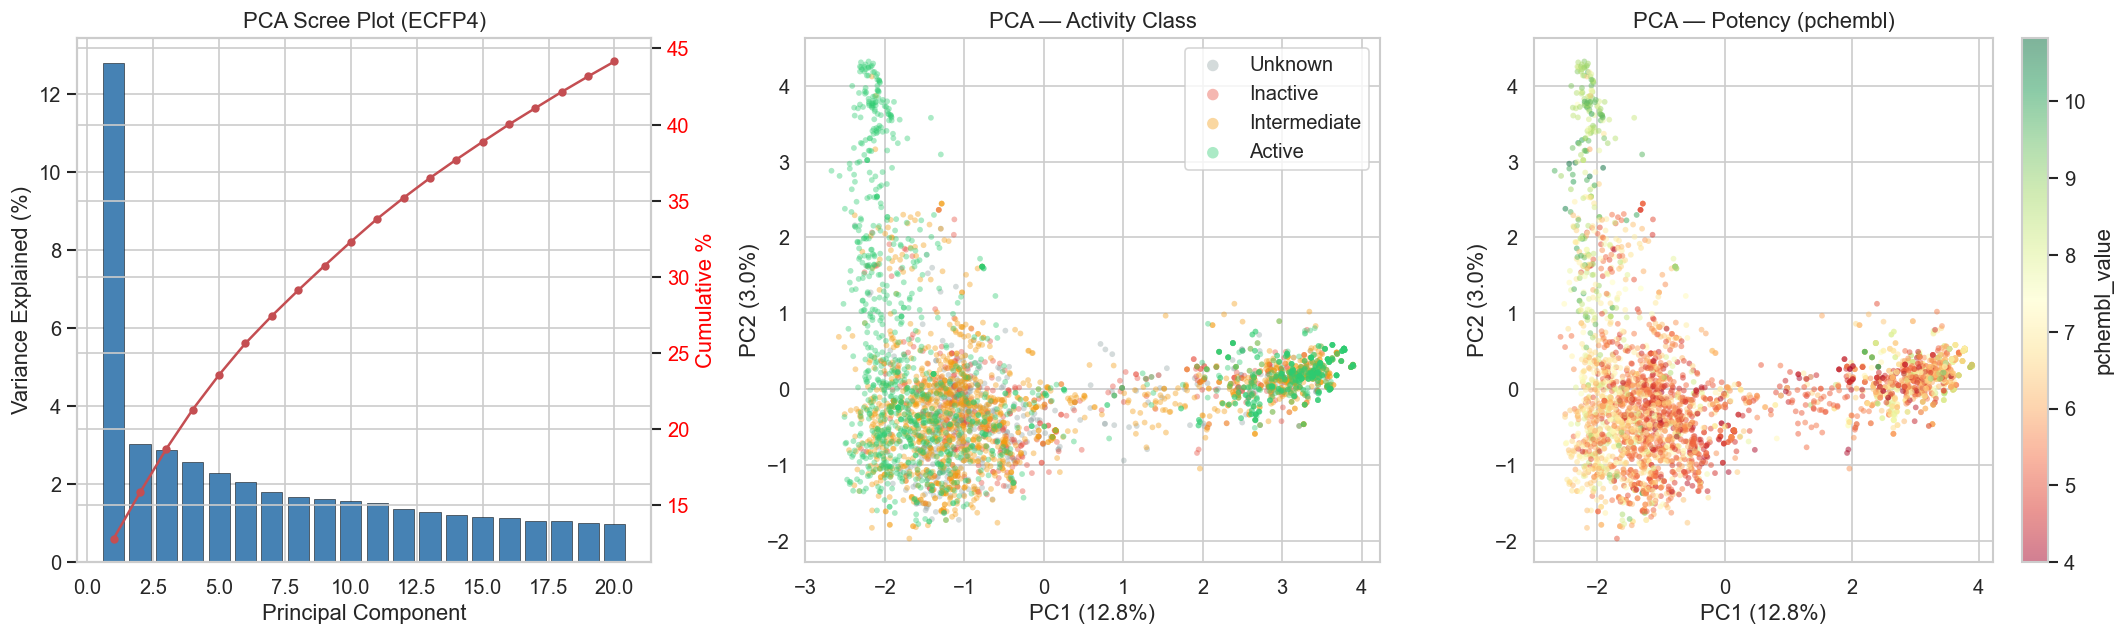


Top 5 PCs explain 23.6% of variance
Top 10 PCs explain 32.3% of variance


In [16]:
# PCA on ECFP4
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_ecfp4)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Variance explained
axes[0].bar(range(1, 21), var_explained * 100, color="steelblue", edgecolor="black", linewidth=0.3)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("PCA Scree Plot (ECFP4)")
cumvar = np.cumsum(var_explained) * 100
ax_twin = axes[0].twinx()
ax_twin.plot(range(1, 21), cumvar, "ro-", markersize=4)
ax_twin.set_ylabel("Cumulative %", color="red")
ax_twin.tick_params(axis="y", labelcolor="red")

# PCA coloured by activity class
color_map_cls = {"Active": "#2ecc71", "Intermediate": "#f39c12", "Inactive": "#e74c3c", "Unknown": "#95a5a6"}
for cls in ["Unknown", "Inactive", "Intermediate", "Active"]:
    mask = df["activity_class"] == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color_map_cls[cls],
                    label=cls, alpha=0.4, s=12, edgecolors="none")
axes[1].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
axes[1].set_title("PCA — Activity Class")
axes[1].legend(markerscale=2)

# PCA coloured by pchembl (continuous)
pch_vals = df["pchembl_value"].values
mask_known = ~np.isnan(pch_vals)
sc = axes[2].scatter(X_pca[mask_known, 0], X_pca[mask_known, 1],
                     c=pch_vals[mask_known], cmap="RdYlGn", s=12, alpha=0.5, edgecolors="none")
axes[2].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
axes[2].set_title("PCA — Potency (pchembl)")
plt.colorbar(sc, ax=axes[2], label="pchembl_value")

plt.tight_layout()
plt.show()

print(f"\nTop 5 PCs explain {cumvar[4]:.1f}% of variance")
print(f"Top 10 PCs explain {cumvar[9]:.1f}% of variance")

Running t-SNE (this may take 1-2 minutes)...


t-SNE done.


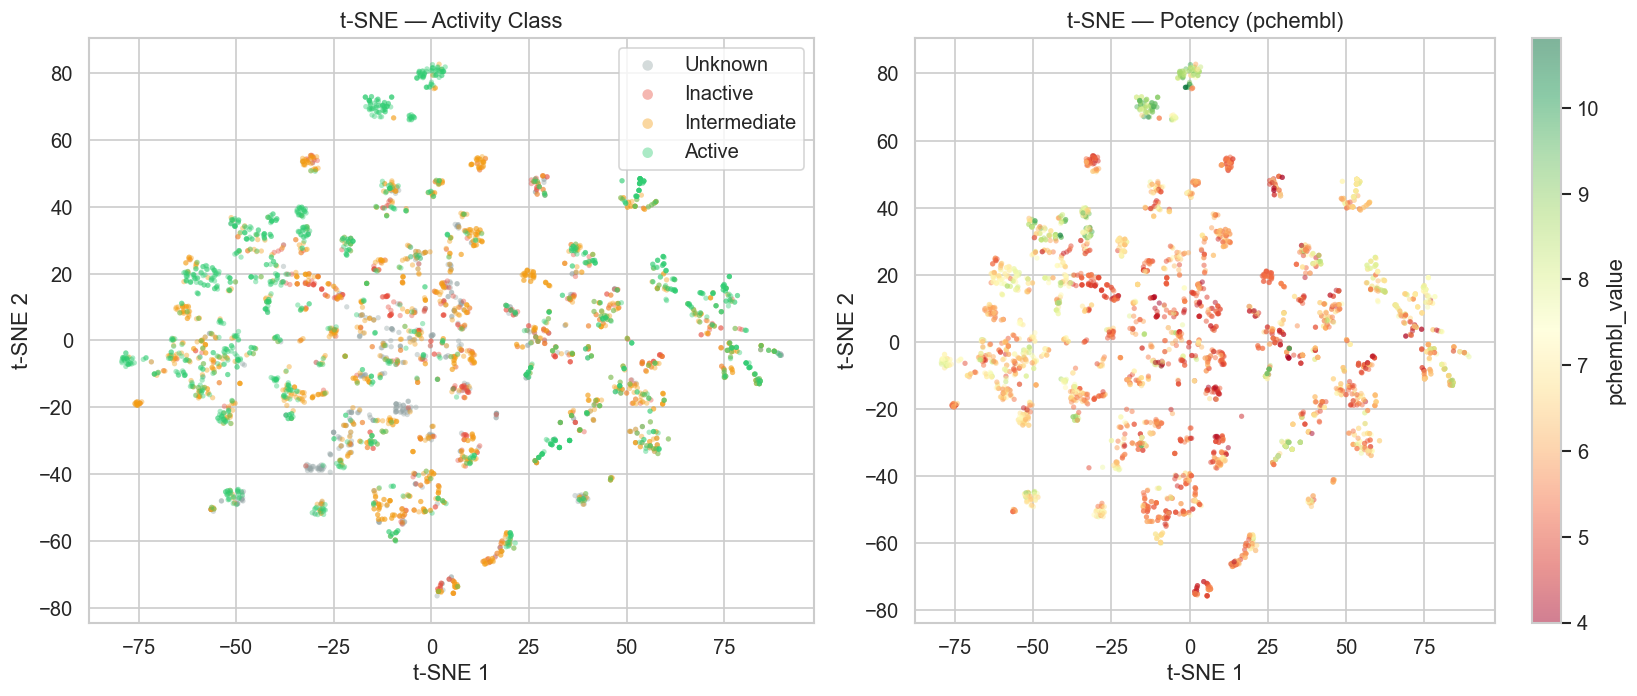

In [17]:
# t-SNE on ECFP4 (use first 50 PCA components to speed up)
print("Running t-SNE (this may take 1-2 minutes)...")
pca50 = PCA(n_components=50, random_state=42)
X_pca50 = pca50.fit_transform(X_ecfp4)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, init="pca")
X_tsne = tsne.fit_transform(X_pca50)
print("t-SNE done.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# By activity class
for cls in ["Unknown", "Inactive", "Intermediate", "Active"]:
    mask = df["activity_class"] == cls
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color_map_cls[cls],
                    label=cls, alpha=0.4, s=10, edgecolors="none")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].set_title("t-SNE — Activity Class")
axes[0].legend(markerscale=2)

# By pchembl (continuous)
sc = axes[1].scatter(X_tsne[mask_known, 0], X_tsne[mask_known, 1],
                     c=pch_vals[mask_known], cmap="RdYlGn", s=10, alpha=0.5, edgecolors="none")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].set_title("t-SNE — Potency (pchembl)")
plt.colorbar(sc, ax=axes[1], label="pchembl_value")

plt.tight_layout()
plt.show()

## 7. Fingerprint Bit Frequency Analysis

MACCS keys: always off=21, always on=0
Rare (<5%): 50, Ubiquitous (>95%): 3
Informative bits (5-95%): 114


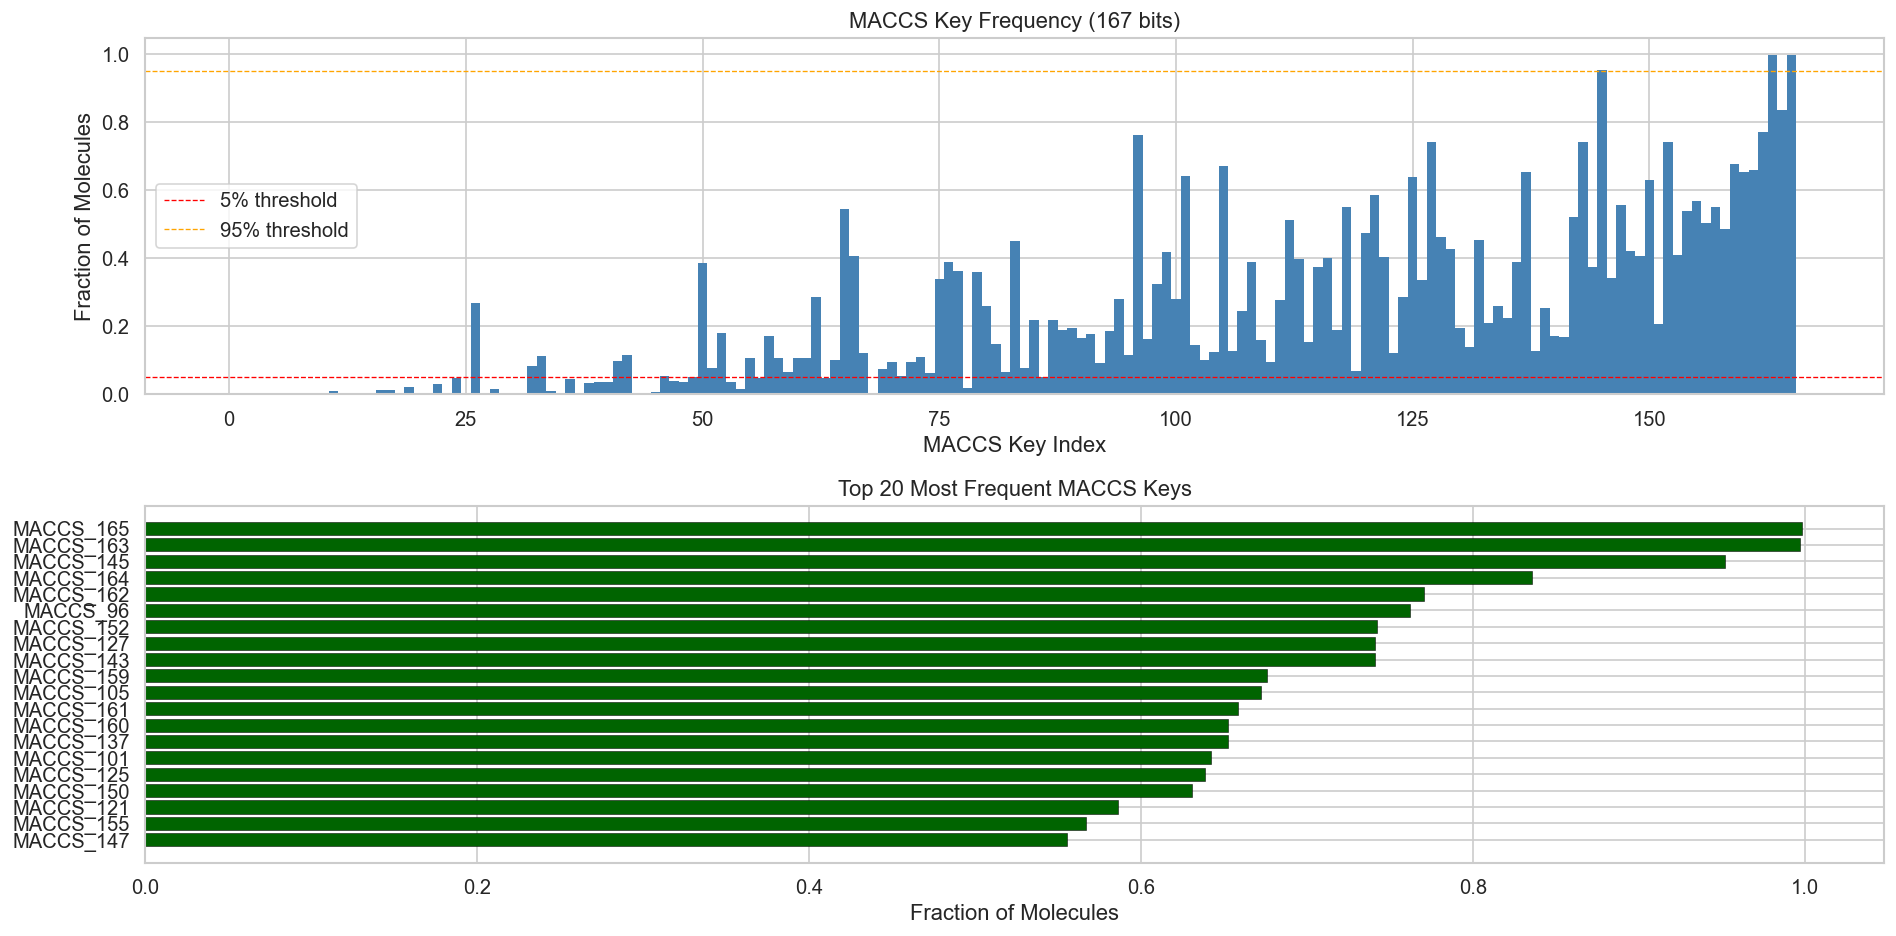

In [18]:
# MACCS key frequencies
fp_maccs = pd.read_csv(f"{FP_DIR}/fingerprints_maccs.csv")
maccs_bits = fp_maccs.iloc[:, 1:].values  # 167 bits
maccs_freq = maccs_bits.mean(axis=0)  # fraction of molecules with each bit set

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Bar chart of all MACCS key frequencies
axes[0].bar(range(len(maccs_freq)), maccs_freq, color="steelblue", edgecolor="none", width=1.0)
axes[0].set_xlabel("MACCS Key Index")
axes[0].set_ylabel("Fraction of Molecules")
axes[0].set_title("MACCS Key Frequency (167 bits)")
axes[0].axhline(0.05, color="red", ls="--", lw=0.8, label="5% threshold")
axes[0].axhline(0.95, color="orange", ls="--", lw=0.8, label="95% threshold")
axes[0].legend()

n_always_off = (maccs_freq == 0).sum()
n_always_on  = (maccs_freq == 1).sum()
n_rare       = (maccs_freq < 0.05).sum()
n_ubiq       = (maccs_freq > 0.95).sum()
print(f"MACCS keys: always off={n_always_off}, always on={n_always_on}")
print(f"Rare (<5%): {n_rare}, Ubiquitous (>95%): {n_ubiq}")
print(f"Informative bits (5-95%): {167 - n_rare - n_ubiq}")

# Top 20 most common MACCS keys
top20_idx = np.argsort(maccs_freq)[::-1][:20]
axes[1].barh(range(20), maccs_freq[top20_idx], color="darkgreen", edgecolor="black", linewidth=0.3)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f"MACCS_{i}" for i in top20_idx])
axes[1].set_xlabel("Fraction of Molecules")
axes[1].set_title("Top 20 Most Frequent MACCS Keys")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

KR FP (4860 bits):
  Always zero: 3415 (70.3%)
  Rare (<1%):  4418 (90.9%)
  Informative (5-95%): 172 (3.5%)
  Bits per molecule: mean=44, median=42, min=1, max=197


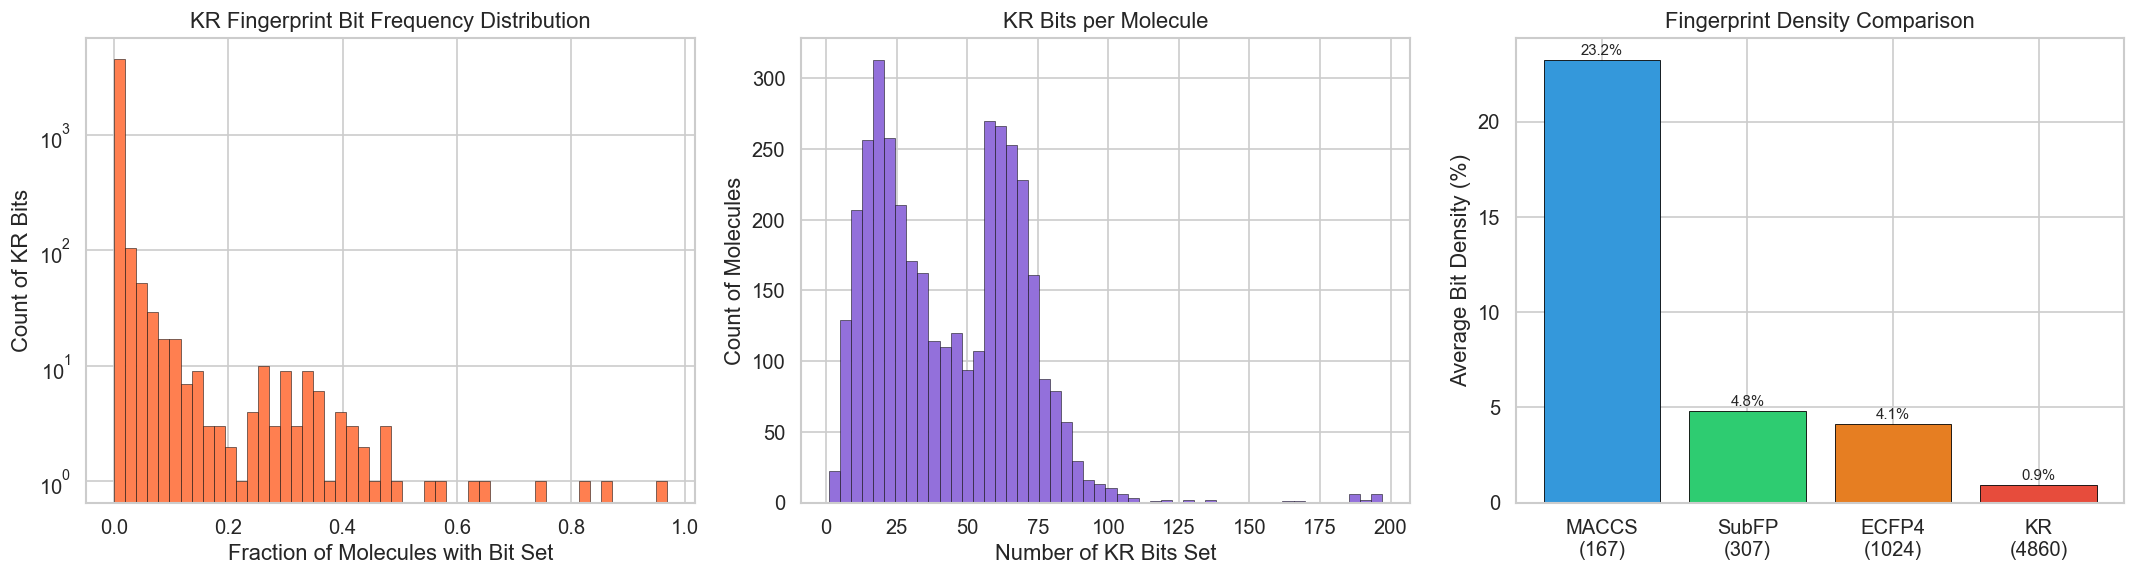

In [19]:
# Klekota-Roth FP sparsity analysis
fp_kr = pd.read_csv(f"{FP_DIR}/fingerprints_kr.csv")
kr_bits = fp_kr.iloc[:, 1:].values  # 4860 bits
kr_freq = kr_bits.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bit frequency distribution
axes[0].hist(kr_freq, bins=50, color="coral", edgecolor="black", linewidth=0.3)
axes[0].set_xlabel("Fraction of Molecules with Bit Set")
axes[0].set_ylabel("Count of KR Bits")
axes[0].set_title("KR Fingerprint Bit Frequency Distribution")
axes[0].set_yscale("log")

n_zero_kr   = (kr_freq == 0).sum()
n_rare_kr   = (kr_freq < 0.01).sum()
n_inform_kr = ((kr_freq >= 0.05) & (kr_freq <= 0.95)).sum()
print(f"KR FP (4860 bits):")
print(f"  Always zero: {n_zero_kr} ({n_zero_kr/4860*100:.1f}%)")
print(f"  Rare (<1%):  {n_rare_kr} ({n_rare_kr/4860*100:.1f}%)")
print(f"  Informative (5-95%): {n_inform_kr} ({n_inform_kr/4860*100:.1f}%)")

# Bits per molecule
bits_per_mol = kr_bits.sum(axis=1)
axes[1].hist(bits_per_mol, bins=50, color="mediumpurple", edgecolor="black", linewidth=0.3)
axes[1].set_xlabel("Number of KR Bits Set")
axes[1].set_ylabel("Count of Molecules")
axes[1].set_title("KR Bits per Molecule")

print(f"  Bits per molecule: mean={bits_per_mol.mean():.0f}, "
      f"median={np.median(bits_per_mol):.0f}, "
      f"min={bits_per_mol.min()}, max={bits_per_mol.max()}")

# Sparsity comparison across all FP types
fp_subfp = pd.read_csv(f"{FP_DIR}/fingerprints_substruct.csv")
subfp_bits = fp_subfp.iloc[:, 1:].values

fps_info = {
    "MACCS\n(167)": maccs_bits,
    "SubFP\n(307)": subfp_bits,
    "ECFP4\n(1024)": X_ecfp4,
    "KR\n(4860)": kr_bits,
}

sparsity_data = []
for name, bits in fps_info.items():
    density = bits.mean()
    sparsity_data.append({"FP": name, "Density": density})

sp_df = pd.DataFrame(sparsity_data)
axes[2].bar(sp_df["FP"], sp_df["Density"] * 100, color=["#3498db", "#2ecc71", "#e67e22", "#e74c3c"],
            edgecolor="black", linewidth=0.5)
axes[2].set_ylabel("Average Bit Density (%)")
axes[2].set_title("Fingerprint Density Comparison")
for i, row in sp_df.iterrows():
    axes[2].text(i, row["Density"] * 100 + 0.3, f"{row['Density']*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Correlation & Feature Importance Preview

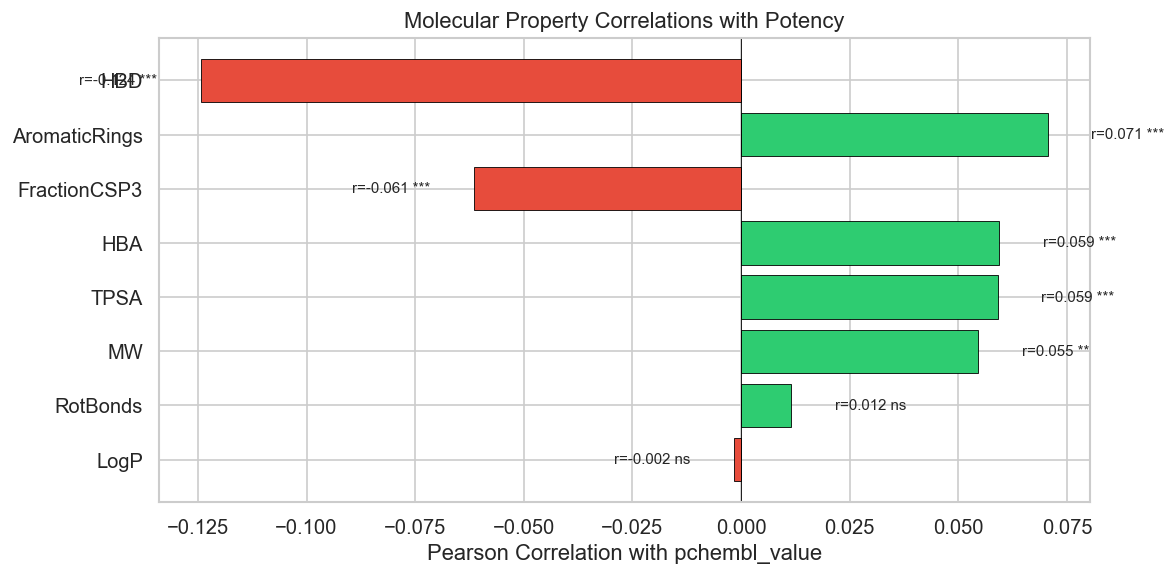

Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant



,pearson_r,p_value
HBD,-0.124278,8.070948e-13
AromaticRings,0.070586,4.994146e-05
FractionCSP3,-0.061440,4.166450e-04
HBA,0.059469,6.357258e-04
TPSA,0.059068,6.917092e-04
MW,0.054572,1.723331e-03
RotBonds,0.011535,5.079530e-01
LogP,-0.001669,9.236889e-01


In [20]:
# Correlation of molecular properties with pchembl_value
pch_mask = df["pchembl_value"].notna()
prop_cols = ["MW", "LogP", "HBA", "HBD", "TPSA", "RotBonds", "AromaticRings", "FractionCSP3"]

corr_data = {}
for col in prop_cols:
    valid = pch_mask & df[col].notna()
    r, p = stats.pearsonr(df.loc[valid, col], df.loc[valid, "pchembl_value"])
    corr_data[col] = {"pearson_r": r, "p_value": p}

corr_df = pd.DataFrame(corr_data).T.sort_values("pearson_r", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_corr = ["#2ecc71" if r > 0 else "#e74c3c" for r in corr_df["pearson_r"]]
ax.barh(corr_df.index, corr_df["pearson_r"], color=colors_corr, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Pearson Correlation with pchembl_value")
ax.set_title("Molecular Property Correlations with Potency")
ax.axvline(0, color="black", lw=0.5)
for i, (idx, row) in enumerate(corr_df.iterrows()):
    sig = "***" if row["p_value"] < 0.001 else "**" if row["p_value"] < 0.01 else "*" if row["p_value"] < 0.05 else "ns"
    ax.text(row["pearson_r"] + (0.01 if row["pearson_r"] > 0 else -0.01),
            i, f"r={row['pearson_r']:.3f} {sig}", va="center",
            ha="left" if row["pearson_r"] > 0 else "right", fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print()
corr_df

Computing top correlated fingerprint bits with pchembl_value...


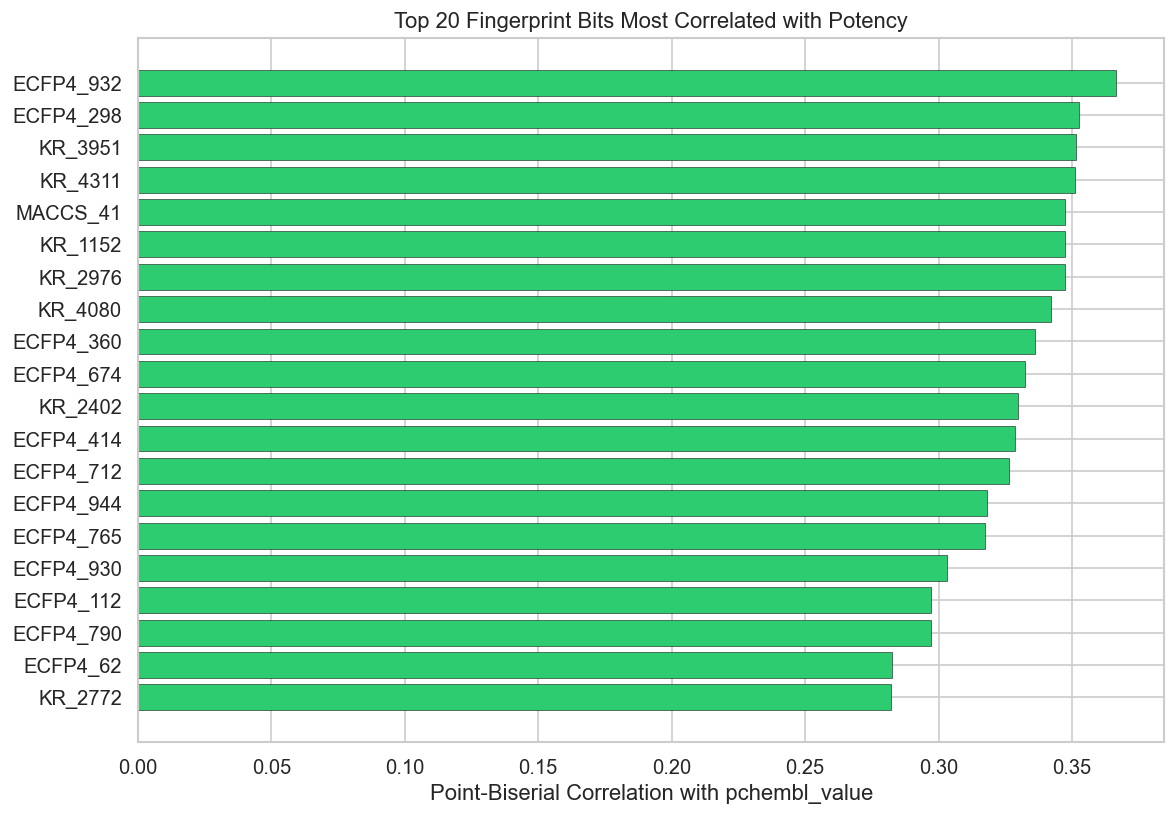


Top 20 bits:
      bit        r             p     freq
ECFP4_932 0.366291 3.392891e-105 0.284587
ECFP4_298 0.352498  4.907563e-97 0.050061
  KR_3951 0.351367  2.200900e-96 0.041262
  KR_4311 0.350949  3.823157e-96 0.041566
 MACCS_41 0.347201  5.230256e-94 0.109527
  KR_1152 0.347201  5.230256e-94 0.109527
  KR_2976 0.347201  5.230256e-94 0.109527
  KR_4080 0.342112  3.732410e-91 0.097998
ECFP4_360 0.336169  6.882935e-88 0.145328
ECFP4_674 0.332522  6.408406e-86 0.132585
  KR_2402 0.329668  2.130608e-84 0.044903
ECFP4_414 0.328511  8.725311e-84 0.045206
ECFP4_712 0.326383  1.149363e-82 0.046117
ECFP4_944 0.318026  2.342185e-78 0.046117
ECFP4_765 0.317291  5.521832e-78 0.051578
ECFP4_930 0.303085  5.464563e-71 0.083434
ECFP4_112 0.297276  3.071858e-68 0.115898
ECFP4_790 0.296958  4.327015e-68 0.147451
 ECFP4_62 0.282600  1.431340e-61 0.044600
  KR_2772 0.282061  2.472439e-61 0.040352


In [21]:
# Top correlated fingerprint bits with pchembl_value (point-biserial correlation)
# Use MACCS (interpretable) + sample of ECFP4 and KR

pch_vals_clean = df.loc[pch_mask, "pchembl_value"].values

def top_correlated_bits(bit_matrix, bit_prefix, n_top=20):
    """Compute point-biserial correlation of each bit with pchembl_value."""
    bit_sub = bit_matrix[pch_mask.values]
    correlations = []
    for i in range(bit_sub.shape[1]):
        bit_col = bit_sub[:, i]
        # Skip constant bits
        if bit_col.std() == 0:
            continue
        r, p = stats.pointbiserialr(bit_col, pch_vals_clean)
        correlations.append({"bit": f"{bit_prefix}_{i}", "r": r, "p": p, "freq": bit_col.mean()})
    cdf = pd.DataFrame(correlations)
    cdf["abs_r"] = cdf["r"].abs()
    return cdf.nlargest(n_top, "abs_r")

print("Computing top correlated fingerprint bits with pchembl_value...")
top_maccs = top_correlated_bits(maccs_bits, "MACCS", 15)
top_ecfp4 = top_correlated_bits(X_ecfp4, "ECFP4", 15)
top_kr    = top_correlated_bits(kr_bits, "KR", 15)

# Combine and show top 20 overall
top_all = pd.concat([top_maccs, top_ecfp4, top_kr]).nlargest(20, "abs_r")

fig, ax = plt.subplots(figsize=(10, 7))
colors_bits = ["#2ecc71" if r > 0 else "#e74c3c" for r in top_all["r"]]
ax.barh(range(len(top_all)), top_all["r"].values, color=colors_bits, edgecolor="black", linewidth=0.3)
ax.set_yticks(range(len(top_all)))
ax.set_yticklabels(top_all["bit"].values)
ax.set_xlabel("Point-Biserial Correlation with pchembl_value")
ax.set_title("Top 20 Fingerprint Bits Most Correlated with Potency")
ax.axvline(0, color="black", lw=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 bits:")
print(top_all[["bit", "r", "p", "freq"]].to_string(index=False))

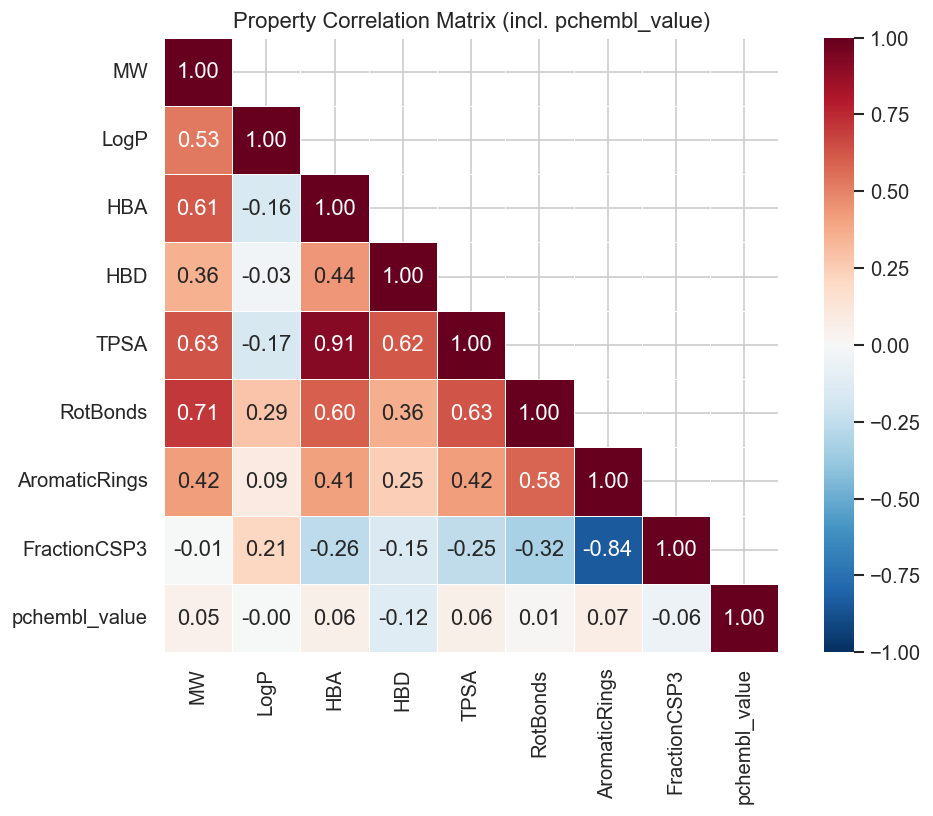

In [22]:
# Inter-property correlation heatmap
prop_with_pch = prop_cols + ["pchembl_value"]
corr_matrix = df[prop_with_pch].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask_tri = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask_tri, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Property Correlation Matrix (incl. pchembl_value)")
plt.tight_layout()
plt.show()

## 9. Summary & QSAR Readiness Assessment

In [23]:
# Compile summary statistics
n_total = len(df)
n_with_pch = df["pchembl_value"].notna().sum()
n_exact = (df["standard_relation"] == "=").sum()
n_exact_pch = df[(df["standard_relation"] == "=") & df["pchembl_value"].notna()].shape[0]

active_n   = (df["activity_class"] == "Active").sum()
inactive_n = (df["activity_class"] == "Inactive").sum()
intermed_n = (df["activity_class"] == "Intermediate").sum()
unknown_n  = (df["activity_class"] == "Unknown").sum()

drug_like_n = (df["Ro5_violations"] == 0).sum()

print("=" * 70)
print("          QSAR READINESS ASSESSMENT — Aromatase (CYP19A1)")
print("=" * 70)
print()
print(f"  Total records:            {n_total:,}")
print(f"  Unique molecules:         {df['molecule_chembl_id'].nunique():,}")
print(f"  With pchembl_value:       {n_with_pch:,} ({n_with_pch/n_total*100:.1f}%)")
print(f"  Exact measurements (=):   {n_exact:,} ({n_exact/n_total*100:.1f}%)")
print(f"  Exact + pchembl:          {n_exact_pch:,}")
print()
print("  Activity class breakdown (pchembl thresholds 6.5 / 5.0):")
print(f"    Active (≥6.5):          {active_n:,}")
print(f"    Intermediate:           {intermed_n:,}")
print(f"    Inactive (<5.0):        {inactive_n:,}")
print(f"    Unknown (no pchembl):   {unknown_n:,}")
print()
print(f"  Drug-like (Ro5, 0 viol.): {drug_like_n:,} ({drug_like_n/n_total*100:.1f}%)")
print()
print("  Fingerprints available:")
print(f"    PubChem CACTVS:         881 bits")
print(f"    MACCS keys:             167 bits")
print(f"    ECFP4 (Morgan r=2):     1,024 bits")
print(f"    CDK SubstructureFP:     307 bits")
print(f"    Klekota-Roth FP:        4,860 bits")
print()
print("  Year range:               "
      f"{df['document_year'].min()} – {df['document_year'].max()}")
print()
print("-" * 70)
print("  RECOMMENDATIONS")
print("-" * 70)
print()
print("  1. REGRESSION: Use exact measurements only (standard_relation='=')")
print(f"     → {n_exact_pch:,} molecules with quantitative pchembl_value")
print()
print("  2. CLASSIFICATION: Use Active/Inactive split (drop Intermediate)")
print(f"     → {active_n:,} active + {inactive_n:,} inactive = {active_n+inactive_n:,} total")
ratio = inactive_n / max(active_n, 1)
print(f"     → Class ratio: 1:{ratio:.2f} (active:inactive) — ", end="")
if 0.5 <= ratio <= 2.0:
    print("BALANCED ✓")
elif ratio <= 5.0:
    print("MODERATE imbalance — consider stratified splits")
else:
    print("SEVERE imbalance — consider SMOTE or class weights")
print()
print("  3. CENSORED DATA: 275 records with '>' relation")
print("     → Exclude from regression, but can include in classification")
print("     → (if pchembl > threshold, still 'active' regardless of censoring)")
print()
print("  4. FINGERPRINT SELECTION:")
print(f"     → ECFP4 (1024 bits): Best for chemical space — PCA/t-SNE show structure")
print(f"     → MACCS (167 bits): Most interpretable — good for feature importance")
print(f"     → KR FP (4860 bits): Richest substructure detail — may need feature selection")
print()
print("  5. DATA SPLITS: Use scaffold-based splitting to avoid data leakage")
print("     → Random splits overestimate performance for congeneric series")
print()
print("=" * 70)
print("  Dataset is READY for QSAR modelling")
print("=" * 70)

          QSAR READINESS ASSESSMENT — Aromatase (CYP19A1)

  Total records:            3,774
  Unique molecules:         3,399
  With pchembl_value:       3,296 (87.3%)
  Exact measurements (=):   3,403 (90.2%)
  Exact + pchembl:          3,290

  Activity class breakdown (pchembl thresholds 6.5 / 5.0):
    Active (≥6.5):          1,435
    Intermediate:           1,431
    Inactive (<5.0):        430
    Unknown (no pchembl):   478

  Drug-like (Ro5, 0 viol.): 2,828 (74.9%)

  Fingerprints available:
    PubChem CACTVS:         881 bits
    MACCS keys:             167 bits
    ECFP4 (Morgan r=2):     1,024 bits
    CDK SubstructureFP:     307 bits
    Klekota-Roth FP:        4,860 bits

  Year range:               1978 – 2024

----------------------------------------------------------------------
  RECOMMENDATIONS
----------------------------------------------------------------------

  1. REGRESSION: Use exact measurements only (standard_relation='=')
     → 3,290 molecules with quan